<a href="https://colab.research.google.com/github/nbontiff/ITAI-1371-ML-Labs/blob/main/L09_NigelBontiff_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Use the Iris dataset to classify flower species.

In [1]:
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Iris dataset
iris = load_iris()

# X = flower measurements
X = iris.data

# y = flower species
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nFeature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

Training data shape: (105, 4)
Testing data shape: (45, 4)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']


Single Decision Tree

In [2]:
single_tree = DecisionTreeClassifier(random_state=42)

single_tree.fit(X_train, y_train)

y_pred_tree = single_tree.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(f"Accuracy of a single Decision Tree: {accuracy_tree:.2%}")

Accuracy of a single Decision Tree: 100.00%


.

In [3]:
# Random Forest model
# n_estimators = 100 decision trees
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest.predict(X_test)

# Calculate the model's accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy of the Random Forest: {accuracy_rf:.2%}")

Accuracy of the Random Forest: 100.00%


Feature Importance

Feature Importance Scores:

sepal length (cm): 0.1041
sepal width (cm): 0.0446
petal length (cm): 0.4173
petal width (cm): 0.4340


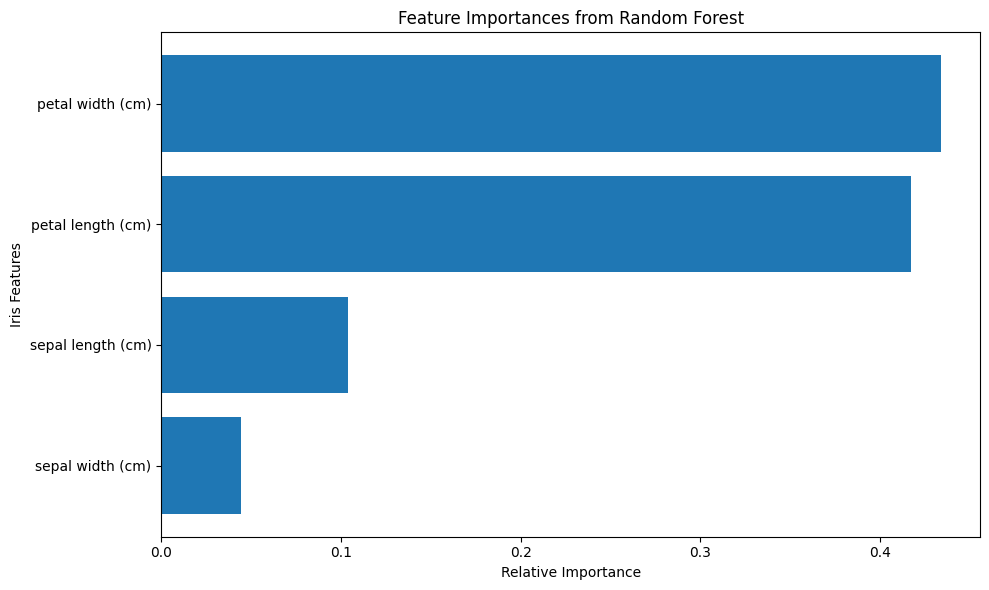

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# feature importance values
importances = random_forest.feature_importances_

# feature names from Iris dataset
feature_names = iris.feature_names

# sort from least to most important
indices = np.argsort(importances)

# Print each feature and its importance 'score'
print("Feature Importance Scores:\n")

for feature, importance in zip(feature_names, importances):
    print(f"{feature}: {importance:.4f}")

# horizontal graph
plt.figure(figsize=(10, 6))

plt.title("Feature Importances from Random Forest")

plt.barh(
    range(len(indices)),
    importances[indices],
    align="center"
)

plt.yticks(
    range(len(indices)),
    [feature_names[i] for i in indices]
)

plt.xlabel("Relative Importance")
plt.ylabel("Iris Features")

plt.tight_layout()
plt.show()

**Knowledge Check**

1. In your own words, what is the main idea behind ensemble methods?

    - The main idea behind ensemble methods is to combine several models instead of depending on only one model. Each model might make different mistakes, so combining their predictions can give a more stable and accurate final answer. A committee of models can be better than one expert model because the models can help balance out each other’s weaknesses instead of letting one model’s mistake decide the final prediction.

2. Which model performed better in this lab?

    - In this lab, the single Decision Tree and the Random Forest both had 100% accuracy, so neither one performed better based on the accuracy score. I expected the Random Forest to possibly perform a little better because it combines many Decision Trees instead of relying on one. However, the Iris dataset is fairly small and the flower species can be separated clearly using the available measurements, so both models were able to classify the test data correctly.

3. Which two features were most important?

    - The two most important features were petal width and petal length. This makes sense because the size and shape of the petals seem like they would be useful for telling different flower species apart. The sepal measurements still had some importance, but the model relied much more heavily on the petal measurements.